In [19]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
movies = pd.read_csv('data/tmdb_5000_movies.csv')
credits = pd.read_csv('data/tmdb_5000_credits.csv')

print(movies.shape)
print(credits.shape)

movies.head()

(4803, 20)
(4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [21]:
movies.info()
credits.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [22]:
movies = movies.merge(credits, on='title')

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [23]:
movies.shape

(4809, 23)

In [24]:
desired_cols = [
    'movie_id','title','overview','genres','keywords','cast','crew',
    'release_date','runtime','vote_average','vote_count','popularity','poster_path'
]

available = [c for c in desired_cols if c in movies.columns]
missing = [c for c in desired_cols if c not in movies.columns]
if missing:
    print("Missing columns (will be skipped):", missing)

movies = movies[available]


Missing columns (will be skipped): ['poster_path']


In [25]:
movies.isnull().sum()

movie_id        0
title           0
overview        3
genres          0
keywords        0
cast            0
crew            0
release_date    1
runtime         2
vote_average    0
vote_count      0
popularity      0
dtype: int64

In [26]:
movies.dropna(subset=['overview'], inplace=True)

In [27]:
movies.duplicated().sum()

np.int64(0)

In [28]:
movies.describe()

,movie_id,runtime,vote_average,vote_count,popularity
count,4806.000000,4806.000000,4806.000000,4806.000000,4806.000000
mean,56922.559509,106.887224,6.093258,690.758427,21.504750
std,88309.447559,22.602261,1.190846,1234.454061,31.808977
min,5.000000,0.000000,0.000000,0.000000,0.000000
25%,9009.750000,94.000000,5.600000,54.000000,4.680875
50%,14615.500000,103.500000,6.200000,236.000000,12.928897
75%,58476.750000,118.000000,6.800000,737.750000,28.350828
max,447027.000000,338.000000,10.000000,13752.000000,875.581305


In [29]:
movies[['title', 'vote_average', 'vote_count', 'popularity']].sort_values(
    by='vote_average', ascending=False
).head(10)

,title,vote_average,vote_count,popularity
4050,"Dancer, Texas Pop. 81",10.0,1,0.376662
4252,Me You and Five Bucks,10.0,2,0.094105
3522,Stiff Upper Lips,10.0,1,0.356495
4668,Little Big Top,10.0,1,0.092100
3997,Sardaarji,9.5,2,0.296981
2388,One Man's Hero,9.3,2,0.910529
1883,The Shawshank Redemption,8.5,8205,136.747729
2973,There Goes My Baby,8.5,2,0.037073
2798,The Prisoner of Zenda,8.4,11,4.021389
3340,The Godfather,8.4,5893,143.659698


In [30]:
movies['release_year'] = pd.to_datetime(
    movies['release_date'], errors='coerce'
).dt.year

In [31]:
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.90)

def weighted_rating(row):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

movies['weighted_tmdb_rating'] = movies.apply(weighted_rating, axis=1)

In [32]:
def runtime_category(runtime):
    if pd.isna(runtime):
        return 'Unknown'
    elif runtime < 90:
        return 'Short'
    elif runtime <= 150:
        return 'Medium'
    else:
        return 'Long'

movies['runtime_category'] = movies['runtime'].apply(runtime_category)

In [33]:
def rating_category(score):
    if score >= 8:
        return 'Excellent'
    elif score >= 7:
        return 'Good'
    elif score >= 6:
        return 'Average'
    else:
        return 'Low'

movies['rating_category'] = movies['weighted_tmdb_rating'].apply(rating_category)

In [34]:
movies['movie_display'] = (
    movies['title'] + 
    ' (' + movies['release_year'].fillna(0).astype(int).astype(str) + ')'
)

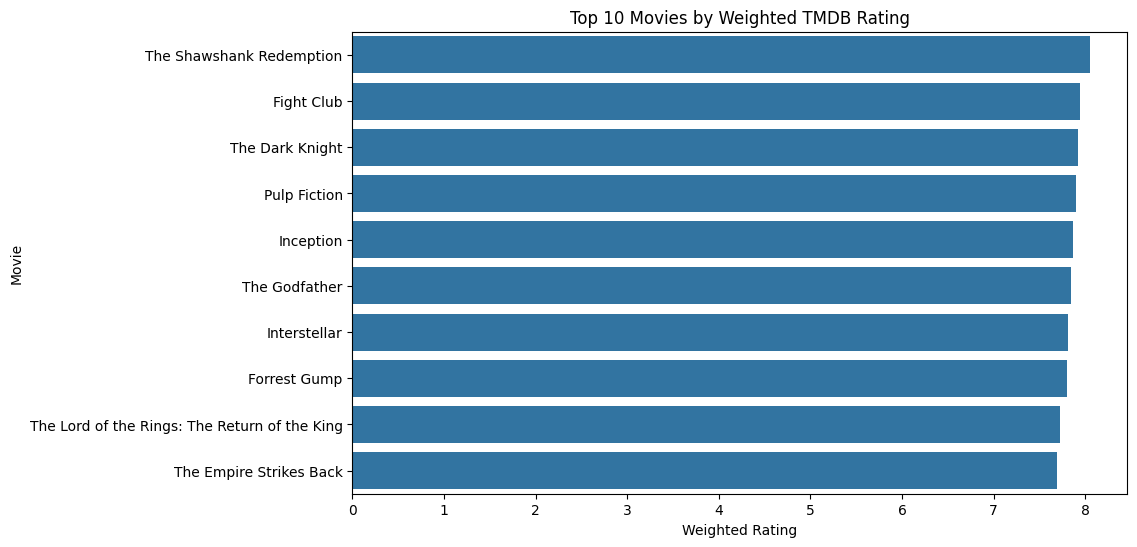

In [35]:
top_rated = movies.sort_values(
    by='weighted_tmdb_rating', ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_rated, x='weighted_tmdb_rating', y='title')
plt.title('Top 10 Movies by Weighted TMDB Rating')
plt.xlabel('Weighted Rating')
plt.ylabel('Movie')
plt.show()

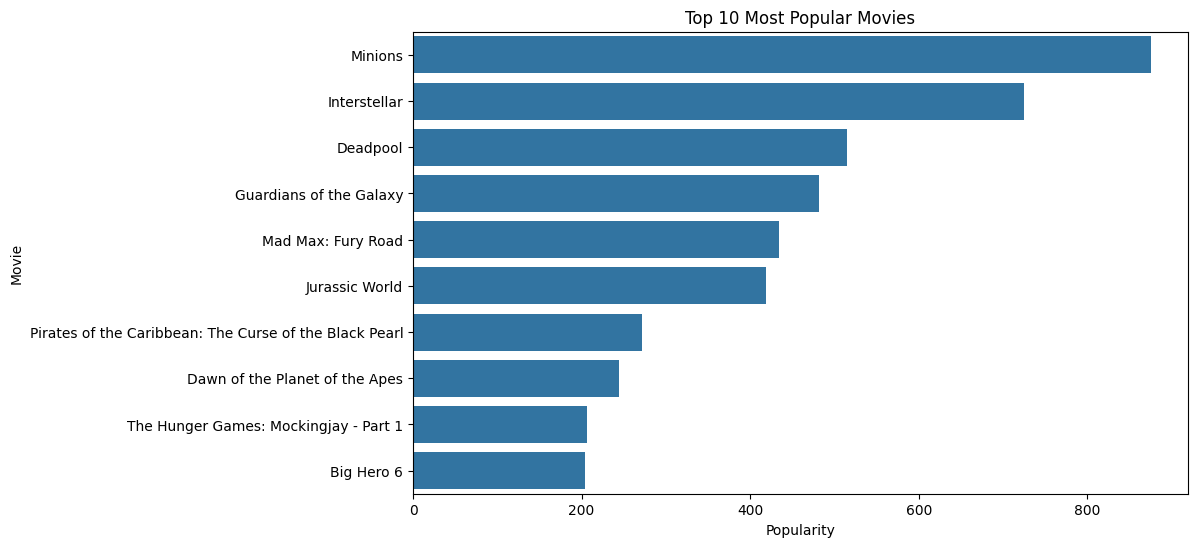

In [36]:
popular_movies = movies.sort_values(
    by='popularity', ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=popular_movies, x='popularity', y='title')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity')
plt.ylabel('Movie')
plt.show()

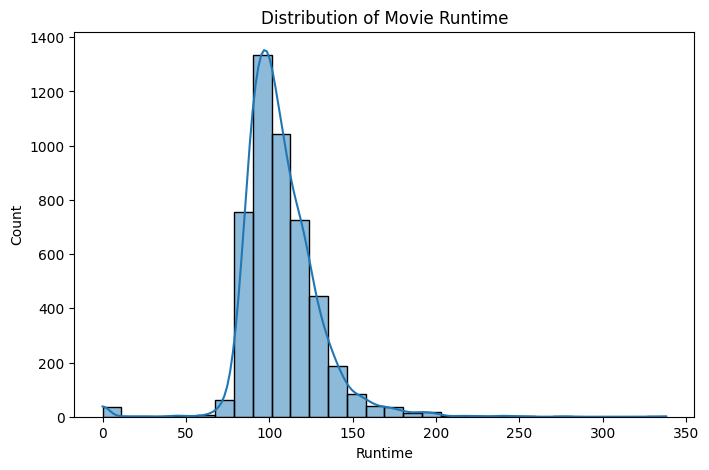

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(movies['runtime'].dropna(), bins=30, kde=True)
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime')
plt.ylabel('Count')
plt.show()

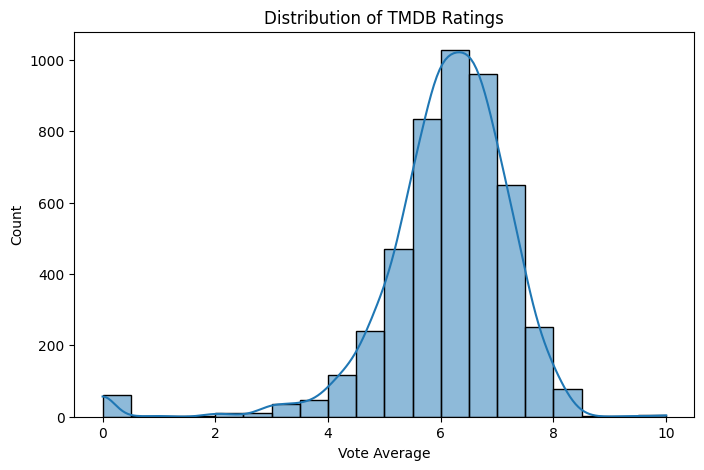

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(movies['vote_average'], bins=20, kde=True)
plt.title('Distribution of TMDB Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.show()

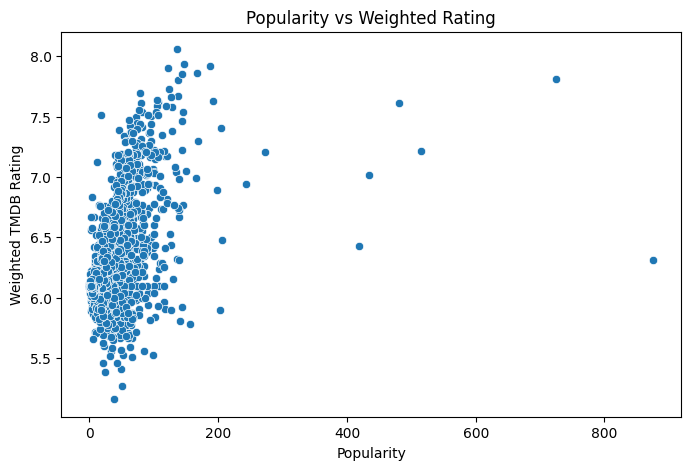

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=movies,
    x='popularity',
    y='weighted_tmdb_rating'
)
plt.title('Popularity vs Weighted Rating')
plt.xlabel('Popularity')
plt.ylabel('Weighted TMDB Rating')
plt.show()

In [40]:
def convert(obj):
    items = []
    for i in ast.literal_eval(obj):
        items.append(i['name'])
    return items

In [41]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [42]:
def convert_cast(obj):
    items = []
    counter = 0
    
    for i in ast.literal_eval(obj):
        if counter < 3:
            items.append(i['name'])
            counter += 1
        else:
            break
            
    return items

In [43]:
movies['cast'] = movies['cast'].apply(convert_cast)

In [44]:
def fetch_director(obj):
    items = []
    
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            items.append(i['name'])
            break
            
    return items

In [45]:
movies['crew'] = movies['crew'].apply(fetch_director)

In [46]:
movies.rename(columns={'crew': 'director'}, inplace=True)

In [47]:
movies['overview'] = movies['overview'].apply(lambda x: x.split())

In [48]:
def remove_spaces(words):
    return [i.replace(" ", "") for i in words]

In [49]:
movies['genres'] = movies['genres'].apply(remove_spaces)
movies['keywords'] = movies['keywords'].apply(remove_spaces)
movies['cast'] = movies['cast'].apply(remove_spaces)
movies['director'] = movies['director'].apply(remove_spaces)

In [50]:
movies['tags'] = (
    movies['overview'] +
    movies['genres'] +
    movies['keywords'] +
    movies['cast'] +
    movies['director']
)

In [51]:
cols = [
    'movie_id',
    'title',
    'movie_display',
    'tags',
    'release_year',
    'runtime',
    'runtime_category',
    'vote_average',
    'vote_count',
    'weighted_tmdb_rating',
    'rating_category',
    'popularity'
]

if 'poster_path' in movies.columns:
    cols.append('poster_path')

new_movies = movies[cols]

In [52]:
def create_poster_url(poster_path):
    if pd.isna(poster_path):
        return "https://via.placeholder.com/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + poster_path

def create_poster_url(poster_path):
    if pd.isna(poster_path):
        return "https://via.placeholder.com/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + poster_path

if 'poster_path' in new_movies.columns:
    new_movies['poster_url'] = new_movies['poster_path'].apply(create_poster_url)
else:
    new_movies['poster_url'] = "https://via.placeholder.com/500x750?text=No+Poster"

In [53]:
new_movies.head()

,movie_id,title,movie_display,tags,release_year,runtime,runtime_category,vote_average,vote_count,weighted_tmdb_rating,rating_category,popularity,poster_url
0,19995,Avatar,Avatar (2009),"[In, the, 22nd, century,, a, paraplegic, Marin...",2009.0,162.0,Long,7.2,11800,7.050318,Good,150.437577,https://via.placeholder.com/500x750?text=No+Po...
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End (2007),"[Captain, Barbossa,, long, believed, to, be, d...",2007.0,169.0,Long,6.9,4500,6.665370,Average,139.082615,https://via.placeholder.com/500x750?text=No+Po...
2,206647,Spectre,Spectre (2015),"[A, cryptic, message, from, Bond’s, past, send...",2015.0,148.0,Medium,6.3,4466,6.239548,Average,107.376788,https://via.placeholder.com/500x750?text=No+Po...
3,49026,The Dark Knight Rises,The Dark Knight Rises (2012),"[Following, the, death, of, District, Attorney...",2012.0,165.0,Long,7.6,9106,7.346090,Good,112.312950,https://via.placeholder.com/500x750?text=No+Po...
4,49529,John Carter,John Carter (2012),"[John, Carter, is, a, war-weary,, former, mili...",2012.0,132.0,Medium,6.1,2124,6.096866,Average,43.926995,https://via.placeholder.com/500x750?text=No+Po...


In [54]:
new_movies[['movie_display', 'poster_url']].head()

,movie_display,poster_url
0,Avatar (2009),https://via.placeholder.com/500x750?text=No+Po...
1,Pirates of the Caribbean: At World's End (2007),https://via.placeholder.com/500x750?text=No+Po...
2,Spectre (2015),https://via.placeholder.com/500x750?text=No+Po...
3,The Dark Knight Rises (2012),https://via.placeholder.com/500x750?text=No+Po...
4,John Carter (2012),https://via.placeholder.com/500x750?text=No+Po...


In [55]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_movies['tags'].apply(lambda x: ' '.join(x))).toarray()

In [56]:
vectors.shape

(4806, 5000)

In [57]:
similarity = cosine_similarity(vectors)

similarity.shape

(4806, 4806)

In [58]:
def recommend(movie):
    movie_index = new_movies[new_movies['title'] == movie].index[0]
    distances = similarity[movie_index]
    
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]
    
    for i in movie_list:
        print(new_movies.iloc[i[0]].title)

In [59]:
recommend('Avatar')

Titan A.E.
Small Soldiers
Independence Day
Ender's Game
Aliens vs Predator: Requiem


In [60]:
def recommend(movie):
    movie_index = new_movies[new_movies['title'] == movie].index[0]
    distances = similarity[movie_index]
    
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:11]
    
    recommendations = []
    
    for i in movie_list:
        recommendations.append({
            'title': new_movies.iloc[i[0]].title,
            'movie_display': new_movies.iloc[i[0]].movie_display,
            'similarity_score': i[1],
            'weighted_tmdb_rating': new_movies.iloc[i[0]].weighted_tmdb_rating,
            'rating_category': new_movies.iloc[i[0]].rating_category
        })
    
    recommendations_df = pd.DataFrame(recommendations)
    
    recommendations_df = recommendations_df.sort_values(
        by=['similarity_score', 'weighted_tmdb_rating'],
        ascending=False
    )
    
    return recommendations_df.head(5)

In [61]:
new_movies['weighted_tmdb_rating'] = movies['weighted_tmdb_rating'].values
new_movies['rating_category'] = movies['rating_category'].values

recommend('The Dark Knight')

,title,movie_display,similarity_score,weighted_tmdb_rating,rating_category
0,The Dark Knight Rises,The Dark Knight Rises (2012),0.423911,7.346090,Good
1,Batman Begins,Batman Begins (2005),0.398031,7.217949,Good
2,Batman Returns,Batman Returns (1992),0.321588,6.334207,Average
3,Batman Forever,Batman Forever (1995),0.287912,5.693049,Low
4,Batman & Robin,Batman & Robin (1997),0.267946,5.270632,Low


In [62]:
new_movies['weighted_tmdb_rating'] = movies['weighted_tmdb_rating'].values
new_movies['rating_category'] = movies['rating_category'].values

recommend('The Godfather')

,title,movie_display,similarity_score,weighted_tmdb_rating,rating_category
0,Desert Dancer,Desert Dancer (2014),0.510113,6.097187,Average
1,Take the Lead,Take the Lead (2006),0.394665,6.134151,Average
2,Step Up 2: The Streets,Step Up 2: The Streets (2008),0.340777,6.197992,Average
3,Center Stage,Center Stage (2000),0.336596,6.126122,Average
4,Footloose,Footloose (1984),0.329956,6.159161,Average


In [63]:
import pickle

pickle.dump(new_movies, open('model.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))

In [64]:
import pickle

test_movies = pickle.load(open('model.pkl', 'rb'))

print(test_movies.columns)
print(test_movies[['movie_display', 'poster_url']].head(10))

Index(['movie_id', 'title', 'movie_display', 'tags', 'release_year', 'runtime',
       'runtime_category', 'vote_average', 'vote_count',
       'weighted_tmdb_rating', 'rating_category', 'popularity', 'poster_url'],
      dtype='str')
                                     movie_display  \
0                                    Avatar (2009)   
1  Pirates of the Caribbean: At World's End (2007)   
2                                   Spectre (2015)   
3                     The Dark Knight Rises (2012)   
4                               John Carter (2012)   
5                              Spider-Man 3 (2007)   
6                                   Tangled (2010)   
7                   Avengers: Age of Ultron (2015)   
8    Harry Potter and the Half-Blood Prince (2009)   
9        Batman v Superman: Dawn of Justice (2016)   

                                          poster_url  
0  https://via.placeholder.com/500x750?text=No+Po...  
1  https://via.placeholder.com/500x750?text=No+Po...  
2  ht

In [65]:
movies_original = pd.read_csv('data/tmdb_5000_movies.csv')

# ensure poster_path exists so the following print won't raise KeyError
if 'poster_path' not in movies_original.columns:
    movies_original['poster_path'] = np.nan

print(movies_original[['title', 'poster_path']].head(10))
print(movies_original['poster_path'].isna().sum())

                                      title  poster_path
0                                    Avatar          NaN
1  Pirates of the Caribbean: At World's End          NaN
2                                   Spectre          NaN
3                     The Dark Knight Rises          NaN
4                               John Carter          NaN
5                              Spider-Man 3          NaN
6                                   Tangled          NaN
7                   Avengers: Age of Ultron          NaN
8    Harry Potter and the Half-Blood Prince          NaN
9        Batman v Superman: Dawn of Justice          NaN
4803


In [66]:
poster_lookup = movies_original[['title', 'poster_path']].copy()

poster_lookup = movies_original[['title', 'poster_path']].copy()

new_df = new_movies.merge(poster_lookup, on='title', how='left')

def create_poster_url(poster_path):
    if pd.isna(poster_path) or poster_path == "":
        return "https://placehold.co/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + str(poster_path)

new_df['poster_url'] = new_df['poster_path'].apply(create_poster_url)

new_df[['title', 'poster_path', 'poster_url']].head(10)

def create_poster_url(poster_path):
    if pd.isna(poster_path) or poster_path == "":
        return "https://placehold.co/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + str(poster_path)

new_df['poster_url'] = new_df['poster_path'].apply(create_poster_url)

new_df[['title', 'poster_path', 'poster_url']].head(10)

,title,poster_path,poster_url
0,Avatar,NaN,https://placehold.co/500x750?text=No+Poster
1,Pirates of the Caribbean: At World's End,NaN,https://placehold.co/500x750?text=No+Poster
2,Spectre,NaN,https://placehold.co/500x750?text=No+Poster
3,The Dark Knight Rises,NaN,https://placehold.co/500x750?text=No+Poster
4,John Carter,NaN,https://placehold.co/500x750?text=No+Poster
5,Spider-Man 3,NaN,https://placehold.co/500x750?text=No+Poster
6,Tangled,NaN,https://placehold.co/500x750?text=No+Poster
7,Avengers: Age of Ultron,NaN,https://placehold.co/500x750?text=No+Poster
8,Harry Potter and the Half-Blood Prince,NaN,https://placehold.co/500x750?text=No+Poster
9,Batman v Superman: Dawn of Justice,NaN,https://placehold.co/500x750?text=No+Poster


In [67]:
pickle.dump(new_df, open('model.pkl', 'wb'))

In [68]:
import pandas as pd
import pickle

# Reload original TMDB movies file
movies_original = pd.read_csv('data/tmdb_5000_movies.csv')

# Create lookup using movie ID
# Reload original TMDB movies file
movies_original = pd.read_csv('data/tmdb_5000_movies.csv')

# Ensure poster_path exists before selecting it
if 'poster_path' not in movies_original.columns:
    movies_original['poster_path'] = pd.NA

# Create lookup using movie ID
poster_lookup = movies_original[['id', 'poster_path']].copy()
poster_lookup = poster_lookup.rename(columns={'id': 'movie_id'})

# Remove old poster columns if they already exist
new_df = new_df.drop(columns=['poster_path', 'poster_url'], errors='ignore')

# Merge poster_path into your final dataframe
new_df = new_df.merge(poster_lookup, on='movie_id', how='left')

# Create full poster URL
def create_poster_url(poster_path):
    if pd.isna(poster_path) or poster_path == "":
        return "https://placehold.co/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + str(poster_path)

new_df['poster_url'] = new_df['poster_path'].apply(create_poster_url)

# Check it worked
new_df[['movie_display', 'poster_path', 'poster_url']].head(10)
poster_lookup = poster_lookup.rename(columns={'id': 'movie_id'})

# Remove old poster columns if they already exist
new_df = new_df.drop(columns=['poster_path', 'poster_url'], errors='ignore')

# Merge poster_path into your final dataframe
new_df = new_df.merge(poster_lookup, on='movie_id', how='left')

# Create full poster URL
def create_poster_url(poster_path):
    if pd.isna(poster_path) or poster_path == "":
        return "https://placehold.co/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + str(poster_path)

new_df['poster_url'] = new_df['poster_path'].apply(create_poster_url)

# Check it worked
new_df[['movie_display', 'poster_path', 'poster_url']].head(10)

,movie_display,poster_path,poster_url
0,Avatar (2009),<NA>,https://placehold.co/500x750?text=No+Poster
1,Pirates of the Caribbean: At World's End (2007),<NA>,https://placehold.co/500x750?text=No+Poster
2,Spectre (2015),<NA>,https://placehold.co/500x750?text=No+Poster
3,The Dark Knight Rises (2012),<NA>,https://placehold.co/500x750?text=No+Poster
4,John Carter (2012),<NA>,https://placehold.co/500x750?text=No+Poster
5,Spider-Man 3 (2007),<NA>,https://placehold.co/500x750?text=No+Poster
6,Tangled (2010),<NA>,https://placehold.co/500x750?text=No+Poster
7,Avengers: Age of Ultron (2015),<NA>,https://placehold.co/500x750?text=No+Poster
8,Harry Potter and the Half-Blood Prince (2009),<NA>,https://placehold.co/500x750?text=No+Poster
9,Batman v Superman: Dawn of Justice (2016),<NA>,https://placehold.co/500x750?text=No+Poster


In [69]:
import pandas as pd

movies_original = pd.read_csv('data/tmdb_5000_movies.csv')

print(movies_original.columns)
movies_original = pd.read_csv('data/tmdb_5000_movies.csv')

print(movies_original.columns)
if 'poster_path' in movies_original.columns:
    print(movies_original[['id', 'title', 'poster_path']].head(20))
else:
    print("poster_path column missing; creating empty poster_path column")
    movies_original['poster_path'] = pd.NA

print(movies_original['poster_path'].isna().sum())
print(movies_original['poster_path'].notna().sum())
print(movies_original['poster_path'].isna().sum())
print(movies_original['poster_path'].notna().sum())

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')
Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')
poster_path column missing; creating empty poster_path column
4803
0
4803
0


In [70]:
import pandas as pd
import pandas as pd
import importlib, subprocess, sys

# ensure requests is available
try:
    import requests
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
    requests = importlib.import_module("requests")

import time
import pickle

API_KEY = "3ec71f396cc1da2d2da96a0ec5567d50"

def fetch_poster_path(movie_id):
    if pd.isna(movie_id):
        return None
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {"api_key": API_KEY, "language": "en-US"}
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            return response.json().get("poster_path")
        return None
    except requests.RequestException:
        return None

# Fetch poster paths with a small delay to avoid rate limits
poster_paths = []
for mid in new_df["movie_id"]:
    poster_paths.append(fetch_poster_path(mid))
    time.sleep(0.25)

new_df["poster_path"] = poster_paths

def create_poster_url(poster_path):
    if pd.isna(poster_path) or poster_path == "":
        return "https://placehold.co/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + str(poster_path)

new_df["poster_url"] = new_df["poster_path"].apply(create_poster_url)

pickle.dump(new_df, open("model.pkl", "wb"))
import time
import pickle

API_KEY = "3ec71f396cc1da2d2da96a0ec5567d50"

def fetch_poster_path(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {"api_key": "3ec71f396cc1da2d2da96a0ec5567d50", "language": "en-US"}

    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            return data.get("poster_path")
        return None
    except:
        return None

new_df["poster_path"] = new_df["movie_id"].apply(fetch_poster_path)

def create_poster_url(poster_path):
    if pd.isna(poster_path) or poster_path == "":
        return "https://placehold.co/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + str(poster_path)

new_df["poster_url"] = new_df["poster_path"].apply(create_poster_url)

pickle.dump(new_df, open("model.pkl", "wb"))

In [71]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [73]:
count_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

count_vectors = count_vectorizer.fit_transform(
    new_df['tags'].apply(lambda x: ' '.join(x) if isinstance(x, (list, tuple)) else (x if isinstance(x, str) else str(x)))
).toarray()

count_similarity = cosine_similarity(count_vectors)

print(count_vectors.shape)
print(count_similarity.shape)

(4818, 5000)
(4818, 4818)


In [75]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

tfidf_vectors = tfidf_vectorizer.fit_transform(
    new_df['tags'].apply(lambda x: ' '.join(x) if isinstance(x, (list, tuple)) else (x if isinstance(x, str) else str(x)))
).toarray()
tfidf_similarity = cosine_similarity(tfidf_vectors)

print(tfidf_vectors.shape)
print(tfidf_similarity.shape)

(4818, 5000)
(4818, 4818)


In [79]:
def recommend_with_similarity(movie, similarity_matrix):
    matching_movies = new_df[new_df['movie_display'] == movie]

    if matching_movies.empty:
        print(f"Movie not found: {movie}")
        print("Try one of these similar titles:")

        suggestions = new_df[
            new_df['movie_display'].str.contains(movie, case=False, na=False)
        ]['movie_display'].head(10)

        display(suggestions)
        return pd.DataFrame()

    movie_index = matching_movies.index[0]
    distances = similarity_matrix[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    recommendations = []

    for i in movie_list:
        recommendations.append({
            'title': new_df.iloc[i[0]].movie_display,
            'rating': round(new_df.iloc[i[0]].weighted_tmdb_rating, 2),
            'category': new_df.iloc[i[0]].rating_category,
            'similarity_score': round(i[1], 3)
        })

    return pd.DataFrame(recommendations)

In [82]:
movie_name = "Avatar (2009)"

In [83]:
count_results = recommend_with_similarity(movie_name, count_similarity)
tfidf_results = recommend_with_similarity(movie_name, tfidf_similarity)

print("CountVectorizer Recommendations")
display(count_results)

print("TF-IDF Recommendations")
display(tfidf_results)

CountVectorizer Recommendations


,title,rating,category,similarity_score
0,Titan A.E. (2000),6.12,Average,0.257
1,Small Soldiers (1998),6.12,Average,0.255
2,Independence Day (1996),6.48,Average,0.249
3,Ender's Game (2013),6.37,Average,0.248
4,Aliens vs Predator: Requiem (2007),5.75,Low,0.246


TF-IDF Recommendations


,title,rating,category,similarity_score
0,Aliens (1986),7.11,Good,0.204
1,Falcon Rising (2014),6.07,Average,0.204
2,Battle: Los Angeles (2011),5.83,Low,0.197
3,Apollo 18 (2011),5.92,Low,0.184
4,Star Trek Into Darkness (2013),7.01,Good,0.171


In [84]:
comparison = pd.DataFrame({
    'CountVectorizer': count_results['title'],
    'Count Similarity Score': count_results['similarity_score'],
    'TF-IDF': tfidf_results['title'],
    'TF-IDF Similarity Score': tfidf_results['similarity_score']
})

comparison

,CountVectorizer,Count Similarity Score,TF-IDF,TF-IDF Similarity Score
0,Titan A.E. (2000),0.257,Aliens (1986),0.204
1,Small Soldiers (1998),0.255,Falcon Rising (2014),0.204
2,Independence Day (1996),0.249,Battle: Los Angeles (2011),0.197
3,Ender's Game (2013),0.248,Apollo 18 (2011),0.184
4,Aliens vs Predator: Requiem (2007),0.246,Star Trek Into Darkness (2013),0.171


In [86]:
test_movies = [
    "Avatar (2009)",
    "The Dark Knight Rises (2012)",
    "Iron Man (2008)",
    "Toy Story (1995)",
    "The Godfather (1972)"
]

for movie in test_movies:
    print("=" * 80)
    print(f"Recommendations for: {movie}")
    
    print("\nCountVectorizer:")
    display(recommend_with_similarity(movie, count_similarity))
    
    print("\nTF-IDF:")
    display(recommend_with_similarity(movie, tfidf_similarity))

Recommendations for: Avatar (2009)

CountVectorizer:


,title,rating,category,similarity_score
0,Titan A.E. (2000),6.12,Average,0.257
1,Small Soldiers (1998),6.12,Average,0.255
2,Independence Day (1996),6.48,Average,0.249
3,Ender's Game (2013),6.37,Average,0.248
4,Aliens vs Predator: Requiem (2007),5.75,Low,0.246



TF-IDF:


,title,rating,category,similarity_score
0,Aliens (1986),7.11,Good,0.204
1,Falcon Rising (2014),6.07,Average,0.204
2,Battle: Los Angeles (2011),5.83,Low,0.197
3,Apollo 18 (2011),5.92,Low,0.184
4,Star Trek Into Darkness (2013),7.01,Good,0.171


Recommendations for: The Dark Knight Rises (2012)

CountVectorizer:


...

,title,rating,category,similarity_score
0,Toy Story 3 (2010),7.17,Good,0.535
1,Toy Story 2 (1999),6.91,Average,0.508
2,The 40 Year Old Virgin (2005),6.15,Average,0.305
3,Factory Girl (2006),6.10,Average,0.158
4,Class of 1984 (1982),6.10,Average,0.155


Recommendations for: The Godfather (1972)

CountVectorizer:


,title,rating,category,similarity_score
0,The Godfather: Part II (1974),7.51,Good,0.435
1,Blood Ties (2013),6.09,Average,0.305
2,Easy Money (2010),6.11,Average,0.305
3,Mi America (2015),6.09,Average,0.302
4,The Godfather: Part III (1990),6.55,Average,0.294



TF-IDF:


,title,rating,category,similarity_score
0,The Godfather: Part II (1974),7.51,Good,0.247
1,The Godfather: Part III (1990),6.55,Average,0.240
2,The Master of Disguise (2002),6.00,Low,0.175
3,Easy Money (2010),6.11,Average,0.155
4,Mickey Blue Eyes (1999),6.04,Average,0.151


In [88]:
def compare_overlap(movie):
    count_titles = set(recommend_with_similarity(movie, count_similarity)['title'])
    tfidf_titles = set(recommend_with_similarity(movie, tfidf_similarity)['title'])

    overlap = count_titles.intersection(tfidf_titles)

    return {
        'movie': movie,
        'count_recommendations': list(count_titles),
        'tfidf_recommendations': list(tfidf_titles),
        'overlap_count': len(overlap),
        'overlap_movies': list(overlap)
    }

compare_overlap("Avatar (2009)")

{'movie': 'Avatar (2009)',
 'count_recommendations': ["Ender's Game (2013)",
  'Titan A.E. (2000)',
  'Aliens vs Predator: Requiem (2007)',
  'Small Soldiers (1998)',
  'Independence Day (1996)'],
 'tfidf_recommendations': ['Star Trek Into Darkness (2013)',
  'Aliens (1986)',
  'Apollo 18 (2011)',
  'Falcon Rising (2014)',
  'Battle: Los Angeles (2011)'],
 'overlap_count': 0,
 'overlap_movies': []}

In [89]:
import pickle

pickle.dump(new_df, open('model.pkl', 'wb'))
pickle.dump(tfidf_similarity, open('similarity.pkl', 'wb'))

In [94]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

new_df['normalised_rating'] = scaler.fit_transform(
    new_df[['weighted_tmdb_rating']]
)

In [95]:
def hybrid_recommend(movie, similarity_matrix, similarity_weight=0.75, rating_weight=0.25, n=5):
    matching_movies = new_df[new_df['movie_display'] == movie]

    if matching_movies.empty:
        print(f"Movie not found: {movie}")
        return pd.DataFrame()

    movie_index = matching_movies.index[0]
    similarity_scores = similarity_matrix[movie_index]

    recommendations = []

    for idx, similarity_score in enumerate(similarity_scores):
        if idx == movie_index:
            continue

        normalised_rating = new_df.iloc[idx]['normalised_rating']

        final_score = (
            similarity_weight * similarity_score
            + rating_weight * normalised_rating
        )

        recommendations.append({
            'title': new_df.iloc[idx]['movie_display'],
            'similarity_score': round(similarity_score, 3),
            'normalised_rating': round(normalised_rating, 3),
            'final_score': round(final_score, 3),
            'weighted_tmdb_rating': round(new_df.iloc[idx]['weighted_tmdb_rating'], 2),
            'rating_category': new_df.iloc[idx]['rating_category']
        })

    recommendations_df = pd.DataFrame(recommendations)

    return recommendations_df.sort_values(
        by='final_score',
        ascending=False
    ).head(n)

In [97]:
hybrid_recommend("Avatar (2009)", tfidf_similarity, n=10)

,title,similarity_score,normalised_rating,final_score,weighted_tmdb_rating,rating_category
2408,Aliens (1986),0.204,0.675,0.322,7.11,Good
3165,Alien (1979),0.136,0.763,0.293,7.37,Good
94,Interstellar (2014),0.083,0.914,0.291,7.81,Good
93,Guardians of the Galaxy (2014),0.106,0.846,0.291,7.61,Good
46,Star Trek Into Darkness (2013),0.171,0.640,0.288,7.01,Good
73,Edge of Tomorrow (2014),0.139,0.699,0.279,7.19,Good
2973,2001: A Space Odyssey (1968),0.099,0.708,0.251,7.21,Good
1886,The Shawshank Redemption (1994),0.000,1.000,0.250,8.06,Excellent
95,Inception (2010),0.021,0.933,0.249,7.86,Good
3631,Moon (2009),0.135,0.579,0.246,6.84,Average


In [98]:
movie_name = "Avatar (2009)"

content_only = recommend_with_similarity(movie_name, count_similarity)
hybrid_results = hybrid_recommend(movie_name, count_similarity, n=5)

print("Content-only recommendations")
display(content_only)

print("Hybrid recommendations")
display(hybrid_results)

Content-only recommendations


,title,rating,category,similarity_score
0,Titan A.E. (2000),6.12,Average,0.257
1,Small Soldiers (1998),6.12,Average,0.255
2,Independence Day (1996),6.48,Average,0.249
3,Ender's Game (2013),6.37,Average,0.248
4,Aliens vs Predator: Requiem (2007),5.75,Low,0.246


Hybrid recommendations


,title,similarity_score,normalised_rating,final_score,weighted_tmdb_rating,rating_category
2408,Aliens (1986),0.237,0.675,0.347,7.11,Good
73,Edge of Tomorrow (2014),0.221,0.699,0.341,7.19,Good
93,Guardians of the Galaxy (2014),0.163,0.846,0.334,7.61,Good
3165,Alien (1979),0.190,0.763,0.334,7.37,Good
94,Interstellar (2014),0.123,0.914,0.321,7.81,Good


In [102]:
import pickle

pickle.dump(new_df, open('model.pkl', 'wb'))
pickle.dump(tfidf_similarity, open('similarity.pkl', 'wb'))

In [120]:
# Power BI-Style Movie Insights Dashboard

# This section explores the movie dataset using dashboard-style charts similar to what could be created in Power BI. 
# The aim is to identify patterns in genres, ratings, popularity, runtime, directors and actors.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from collections import Counter
import seaborn as sns

In [123]:
movies_raw = pd.read_csv("data/tmdb_5000_movies.csv")
credits_raw = pd.read_csv("data/tmdb_5000_credits.csv")

print("Movies shape:", movies_raw.shape)
print("Credits shape:", credits_raw.shape)

movies_raw.head()

Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [124]:
dashboard_df = movies_raw.merge(
    credits_raw,
    left_on="title",
    right_on="title",
    how="left"
)

print(dashboard_df.shape)
dashboard_df.head()

(4809, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [125]:
def extract_names(text):
    """
    Extracts the 'name' values from JSON-like text columns.
    Works for genres, keywords, cast and similar TMDB fields.
    """
    try:
        items = ast.literal_eval(text)
        return [item["name"] for item in items]
    except:
        return []


def extract_director(text):
    """
    Extracts the director from the crew column.
    """
    try:
        crew = ast.literal_eval(text)
        for person in crew:
            if person.get("job") == "Director":
                return person.get("name")
        return None
    except:
        return None


def extract_top_cast(text, n=5):
    """
    Extracts the first n cast members from the cast column.
    """
    try:
        cast = ast.literal_eval(text)
        return [person["name"] for person in cast[:n]]
    except:
        return []

In [126]:
dashboard_df["genre_list"] = dashboard_df["genres"].apply(extract_names)
dashboard_df["director"] = dashboard_df["crew"].apply(extract_director)
dashboard_df["top_cast"] = dashboard_df["cast"].apply(lambda x: extract_top_cast(x, n=5))

dashboard_df["release_date"] = pd.to_datetime(
    dashboard_df["release_date"],
    errors="coerce"
)

dashboard_df["release_year"] = dashboard_df["release_date"].dt.year

dashboard_df[[
    "title",
    "genre_list",
    "director",
    "top_cast",
    "vote_average",
    "popularity",
    "runtime",
    "release_year"
]].head()

,title,genre_list,director,top_cast,vote_average,popularity,runtime,release_year
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]",James Cameron,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",7.2,150.437577,162.0,2009.0
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",Gore Verbinski,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...",6.9,139.082615,169.0,2007.0
2,Spectre,"[Action, Adventure, Crime]",Sam Mendes,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",6.3,107.376788,148.0,2015.0
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",Christopher Nolan,"[Christian Bale, Michael Caine, Gary Oldman, A...",7.6,112.312950,165.0,2012.0
4,John Carter,"[Action, Adventure, Science Fiction]",Andrew Stanton,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...",6.1,43.926995,132.0,2012.0


In [127]:
all_genres = []

for genres in dashboard_df["genre_list"]:
    all_genres.extend(genres)

genre_counts = Counter(all_genres)

top_genres = pd.DataFrame(
    genre_counts.most_common(10),
    columns=["Genre", "Movie Count"]
)

top_genres

,Genre,Movie Count
0,Drama,2300
1,Comedy,1723
2,Thriller,1275
3,Action,1156
4,Romance,895
5,Adventure,792
6,Crime,697
7,Science Fiction,538
8,Horror,520
9,Family,514


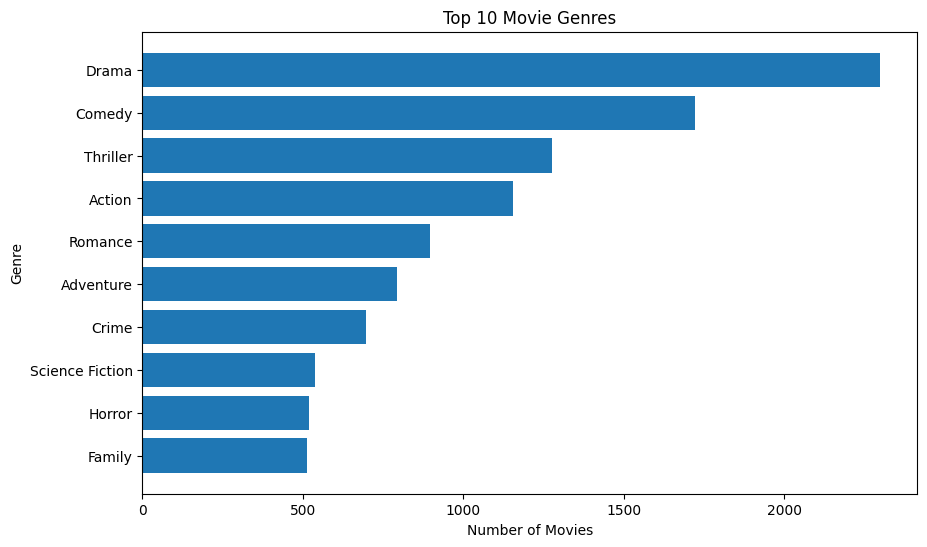

In [128]:
plt.figure(figsize=(10, 6))
plt.barh(top_genres["Genre"], top_genres["Movie Count"])
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Top 10 Movie Genres")
plt.gca().invert_yaxis()
plt.show()

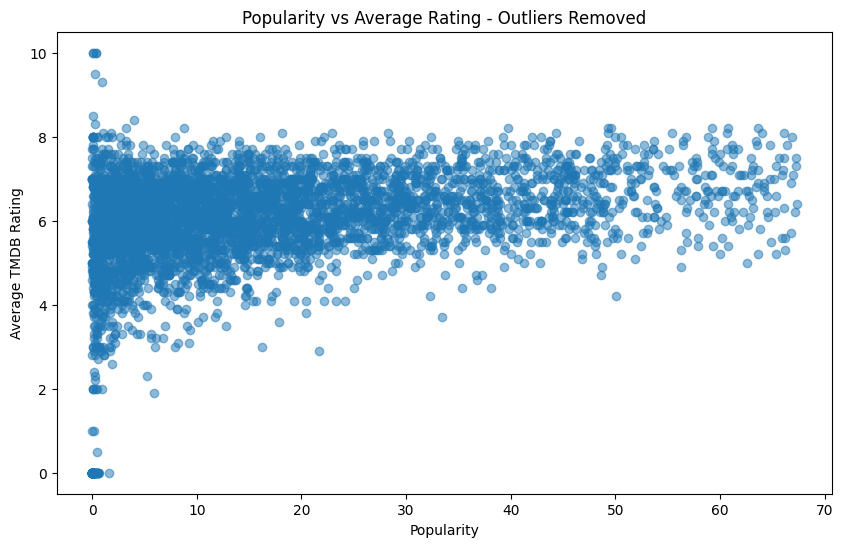

In [131]:
popularity_limit = dashboard_df["popularity"].quantile(0.95)

popularity_filtered = dashboard_df[
    dashboard_df["popularity"] <= popularity_limit
]

plt.figure(figsize=(10, 6))
plt.scatter(
    popularity_filtered["popularity"],
    popularity_filtered["vote_average"],
    alpha=0.5
)

plt.xlabel("Popularity")
plt.ylabel("Average TMDB Rating")
plt.title("Popularity vs Average Rating - Outliers Removed")
plt.show()

In [132]:
runtime_df = dashboard_df.dropna(subset=["runtime", "release_year"])

runtime_df = runtime_df[
    (runtime_df["runtime"] > 0) &
    (runtime_df["release_year"] >= 1960)
]

In [133]:
runtime_trend = runtime_df.groupby("release_year")["runtime"].mean().reset_index()

runtime_trend.head()

,release_year,runtime
0,1960.0,126.666667
1,1961.0,146.400000
2,1962.0,141.571429
3,1963.0,150.125000
4,1964.0,121.200000


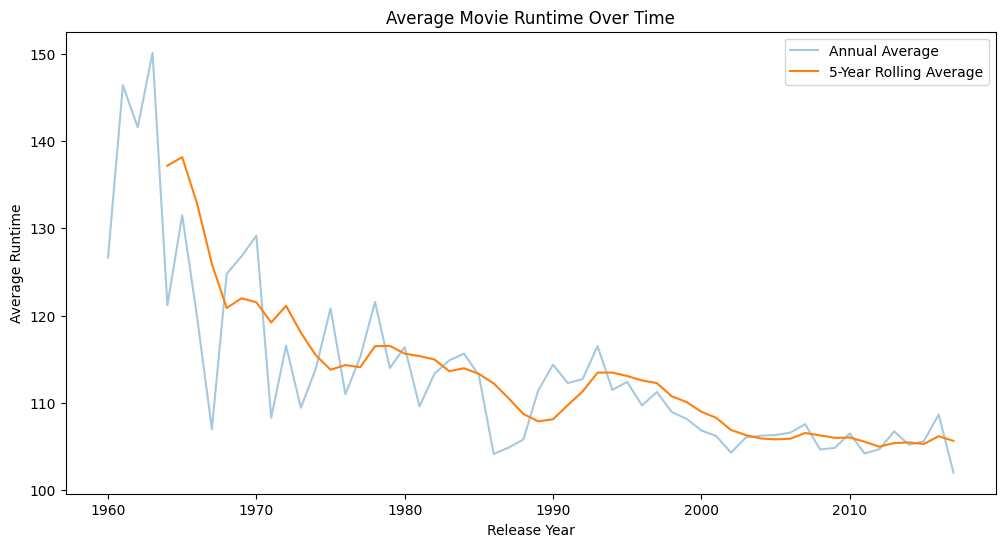

In [135]:
runtime_trend["runtime_rolling_avg"] = runtime_trend["runtime"].rolling(window=5).mean()

plt.figure(figsize=(12, 6))
plt.plot(runtime_trend["release_year"], runtime_trend["runtime"], alpha=0.4, label="Annual Average")
plt.plot(runtime_trend["release_year"], runtime_trend["runtime_rolling_avg"], label="5-Year Rolling Average")
plt.xlabel("Release Year")
plt.ylabel("Average Runtime")
plt.title("Average Movie Runtime Over Time")
plt.legend()
plt.show()

In [136]:
director_counts = dashboard_df["director"].dropna().value_counts().head(10)

top_directors = director_counts.reset_index()
top_directors.columns = ["Director", "Movie Count"]

top_directors

,Director,Movie Count
0,Steven Spielberg,27
1,Woody Allen,21
2,Martin Scorsese,20
3,Clint Eastwood,20
4,Ridley Scott,16
5,Robert Rodriguez,16
6,Spike Lee,16
7,Tim Burton,15
8,Steven Soderbergh,15
9,Renny Harlin,15


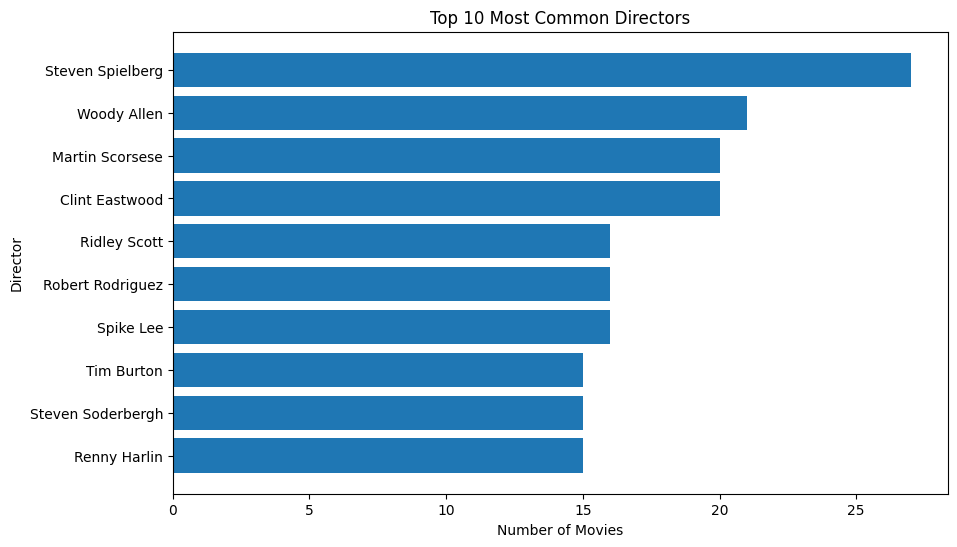

In [137]:
plt.figure(figsize=(10, 6))
plt.barh(top_directors["Director"], top_directors["Movie Count"])
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.title("Top 10 Most Common Directors")
plt.gca().invert_yaxis()
plt.show()

In [138]:
all_actors = []

for cast_list in dashboard_df["top_cast"]:
    all_actors.extend(cast_list)

actor_counts = Counter(all_actors)

top_actors = pd.DataFrame(
    actor_counts.most_common(10),
    columns=["Actor", "Movie Count"]
)

top_actors

,Actor,Movie Count
0,Robert De Niro,54
1,Samuel L. Jackson,44
2,Bruce Willis,39
3,Matt Damon,36
4,Nicolas Cage,35
5,Morgan Freeman,35
6,Johnny Depp,32
7,Brad Pitt,32
8,Mark Wahlberg,31
9,Owen Wilson,31


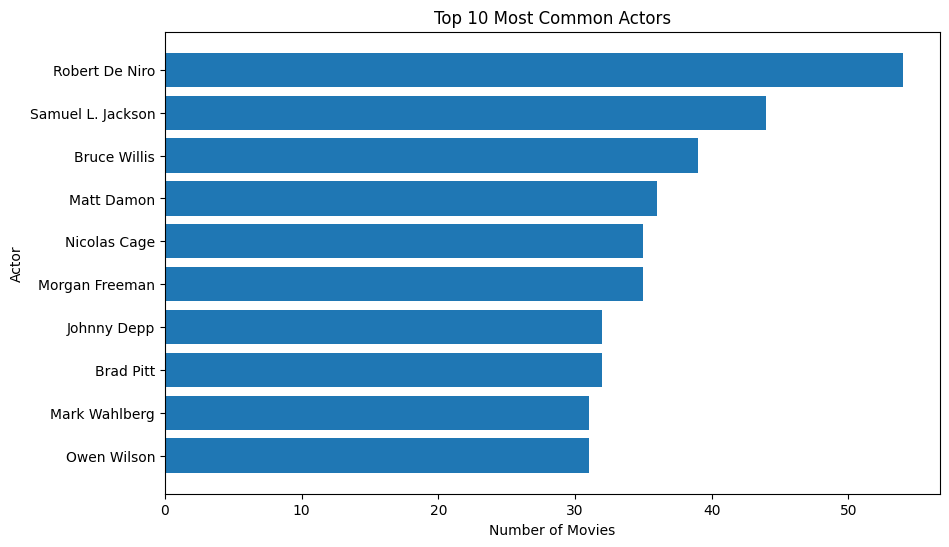

In [139]:
plt.figure(figsize=(10, 6))
plt.barh(top_actors["Actor"], top_actors["Movie Count"])
plt.xlabel("Number of Movies")
plt.ylabel("Actor")
plt.title("Top 10 Most Common Actors")
plt.gca().invert_yaxis()
plt.show()

In [140]:
total_movies = dashboard_df["title"].nunique()
average_rating = dashboard_df["vote_average"].mean()
average_runtime = dashboard_df["runtime"].mean()
total_directors = dashboard_df["director"].nunique()
total_genres = len(set(all_genres))

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Movies",
        "Average Rating",
        "Average Runtime",
        "Unique Directors",
        "Unique Genres"
    ],
    "Value": [
        total_movies,
        round(average_rating, 2),
        round(average_runtime, 1),
        total_directors,
        total_genres
    ]
})

kpi_summary

,Metric,Value
0,Total Movies,4800.00
1,Average Rating,6.09
2,Average Runtime,106.90
3,Unique Directors,2349.00
4,Unique Genres,20.00


In [141]:
top_rated_movies = dashboard_df[
    dashboard_df["vote_count"] >= 500
].sort_values(
    by="vote_average",
    ascending=False
)[["title", "vote_average", "vote_count", "popularity"]].head(10)

top_rated_movies

,title,vote_average,vote_count,popularity
1883,The Shawshank Redemption,8.5,8205,136.747729
3340,The Godfather,8.4,5893,143.659698
662,Fight Club,8.3,9413,146.757391
2733,The Godfather: Part II,8.3,3338,105.792936
3235,Pulp Fiction,8.3,8428,121.463076
1820,Schindler's List,8.3,4329,104.469351
2296,Spirited Away,8.3,3840,118.968562
3870,Whiplash,8.3,4254,192.528841
65,The Dark Knight,8.2,12002,187.322927
3724,One Flew Over the Cuckoo's Nest,8.2,2919,127.525581


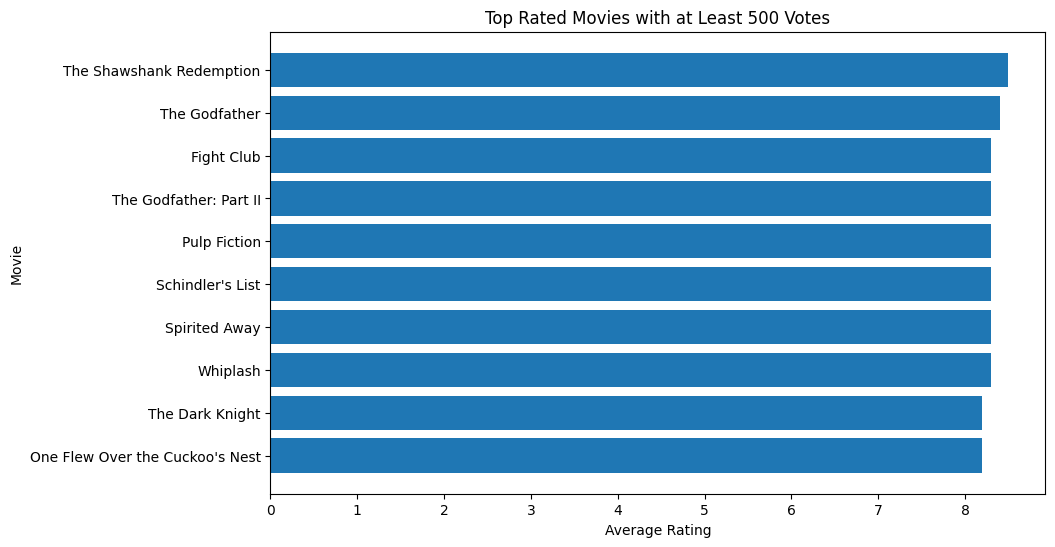

In [142]:
plt.figure(figsize=(10, 6))
plt.barh(top_rated_movies["title"], top_rated_movies["vote_average"])
plt.xlabel("Average Rating")
plt.ylabel("Movie")
plt.title("Top Rated Movies with at Least 500 Votes")
plt.gca().invert_yaxis()
plt.show()

In [143]:
financial_df = dashboard_df[
    (dashboard_df["budget"] > 0) &
    (dashboard_df["revenue"] > 0)
].copy()

financial_df["profit"] = financial_df["revenue"] - financial_df["budget"]

top_profit_movies = financial_df.sort_values(
    by="profit",
    ascending=False
)[["title", "budget", "revenue", "profit"]].head(10)

top_profit_movies

,title,budget,revenue,profit
0,Avatar,237000000,2787965087,2550965087
25,Titanic,200000000,1845034188,1645034188
28,Jurassic World,150000000,1513528810,1363528810
44,Furious 7,190000000,1506249360,1316249360
16,The Avengers,220000000,1519557910,1299557910
7,Avengers: Age of Ultron,280000000,1405403694,1125403694
124,Frozen,150000000,1274219009,1124219009
546,Minions,74000000,1156730962,1082730962
329,The Lord of the Rings: The Return of the King,94000000,1118888979,1024888979
31,Iron Man 3,200000000,1215439994,1015439994


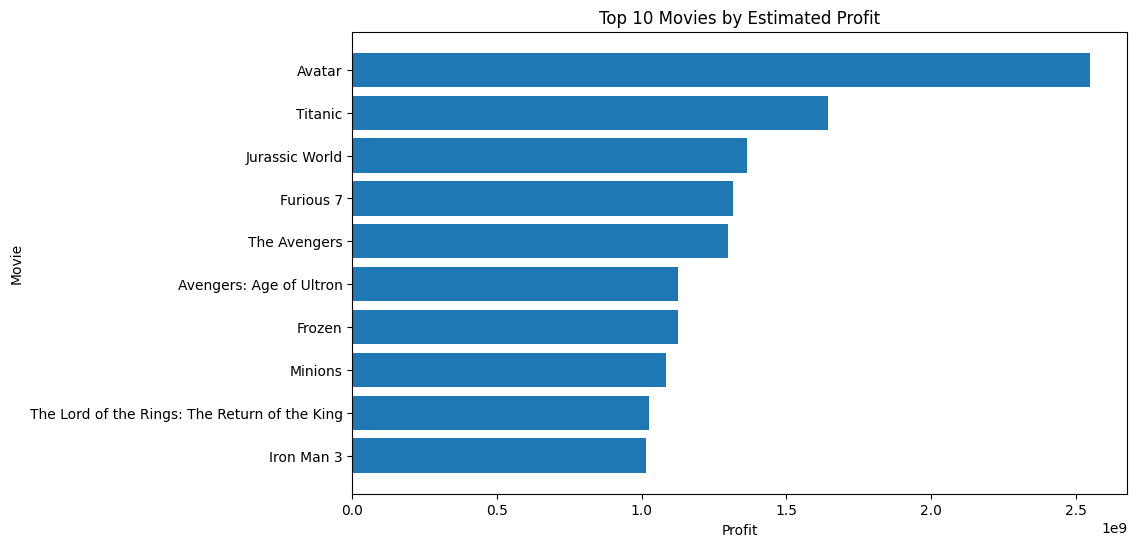

In [144]:
plt.figure(figsize=(10, 6))
plt.barh(top_profit_movies["title"], top_profit_movies["profit"])
plt.xlabel("Profit")
plt.ylabel("Movie")
plt.title("Top 10 Movies by Estimated Profit")
plt.gca().invert_yaxis()
plt.show()